# planes semaforicos

In [20]:
from datetime import datetime, timedelta
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import gspread
from google.oauth2 import service_account
from googleapiclient.discovery import build
import requests
import gspread_dataframe as gd
import google.auth
import google.auth.transport.requests
import pandas as pd
import numpy as np
import io

from sqlalchemy.engine import create_engine
from sqlalchemy.dialects.oracle import (FLOAT,NUMBER,VARCHAR2,TIMESTAMP,DATE,VARCHAR)
from sqlalchemy import Float, Numeric
from sqlalchemy import delete, text
import plotly.express as pex

import plotly.io as pio
pio.renderers.default = 'browser'

In [4]:
username = "SEMAFORIZACION"
password = "S3M4F0R0S2025"
host = "192.168.100.83"
port = "1521"
sid = "GEOS"

dsn = f"oracle+oracledb://{username}:{password}@{host}:{port}/{sid}"
engine = create_engine(dsn, thick_mode={})

In [27]:
sem = 1
now = datetime.now()

day1=(now - timedelta(weeks=sem)).strftime("%d/%m/%y")
day2=(now + timedelta(days=1)).strftime("%d/%m/%y")

In [28]:
day1

'26/03/26'

In [29]:
select_template = '''SELECT * FROM PLAN_HIST_SEMA WHERE "Tiempo" >= TO_DATE('{day_base}','DD/MM/RR') AND "Tiempo" <= TO_DATE('{day_fin}','DD/MM/RR') '''   #
query = select_template.format(day_base = day1, day_fin = day2)
Hist_sem = pd.read_sql(query, engine)
lista_ext = sorted(Hist_sem['Externo'].unique())
lista_ext = [np.int64(x) for x in lista_ext]

In [30]:
deteccion_template = '''SELECT * FROM DET_RESUM_SEMA_15M WHERE "Tiempo" >= TO_DATE('{day_base}','DD/MM/RR') AND "Tiempo" <= TO_DATE('{day_fin}','DD/MM/RR') '''   #
query_det = deteccion_template.format(day_base = day1, day_fin = day2)
Hist_det = pd.read_sql(query_det, engine)

In [31]:
Hist_det.head(10)

,Tiempo,ig,ext,Movimiento,Acceso,Tipo_sensor,Sensor,Num_deteccion,Deteccion,Ocupacion,Brecha,Velocidad,Dia_sem,Hora,Minuto,Fecha
0,2026-04-01 04:14:00,11,1355,D5,2,W,W.2.2,16,11,0.3333,81.545,79.200,3 Wednesday,4,04:14:00,2026-04-01
1,2026-04-01 04:29:00,11,1355,D5,2,W,W.2.2,16,3,0.1333,299.600,54.000,3 Wednesday,4,04:29:00,2026-04-01
2,2026-04-01 04:44:00,11,1355,D5,2,W,W.2.2,16,14,1.8622,63.089,18.043,3 Wednesday,4,04:44:00,2026-04-01
3,2026-04-01 04:59:00,11,1355,D5,2,W,W.2.2,16,20,6.8644,41.911,6.993,3 Wednesday,4,04:59:00,2026-04-01
4,2026-04-01 05:14:00,11,1355,D5,2,W,W.2.2,16,24,7.8033,34.574,7.381,3 Wednesday,5,05:14:00,2026-04-01
5,2026-04-01 05:29:00,11,1355,D5,2,W,W.2.2,16,30,13.1289,26.061,5.484,3 Wednesday,5,05:29:00,2026-04-01
6,2026-04-01 05:44:00,11,1355,D5,2,W,W.2.2,16,52,18.4878,14.108,6.750,3 Wednesday,5,05:44:00,2026-04-01
7,2026-04-01 05:59:00,11,1355,D5,2,W,W.2.2,16,48,23.9856,14.253,4.803,3 Wednesday,5,05:59:00,2026-04-01
8,2026-04-01 06:14:00,11,1355,D5,2,W,W.2.2,16,77,31.5633,7.999,5.855,3 Wednesday,6,06:14:00,2026-04-01
9,2026-04-01 06:29:00,11,1355,D5,2,W,W.2.2,16,81,36.0978,7.100,5.385,3 Wednesday,6,06:29:00,2026-04-01


Hist_det

In [13]:
data=[]
for EXT in lista_ext:
    planes_sel=Hist_sem[(Hist_sem["Externo"] == EXT)].sort_values(by=['Referencia'], ascending=False)
    nuevo = planes_sel[["Referencia", "Externo", "Plan_ingresa", "Tiempo"]].reset_index(drop=True)
    inicio = pd.DataFrame({'fecha_inicio': nuevo['Tiempo'].dt.date,'hora_inicio': nuevo['Tiempo'].dt.time})
    nuevo =pd.concat([nuevo, inicio],axis = 1)

    movido =planes_sel[["Plan_finaliza", "Tiempo"]]
    add = pd.DataFrame({'Plan_finaliza': planes_sel.iloc[0, 2],'Tiempo': planes_sel.iloc[0, 0].to_period("d").to_timestamp(how="end").round('1s') - timedelta(seconds=1)}, index=[0])
    prueba = pd.concat([add, movido], ignore_index = True).set_axis(['Plan_finaliza', 'Tiempo_finaliza'], axis=1)[:-1]
    tiempos = pd.DataFrame({'fecha_finaliza': prueba['Tiempo_finaliza'].dt.date,'hora_finaliza': prueba['Tiempo_finaliza'].dt.time})
    prueba = pd.concat([prueba, tiempos],axis = 1)

    Union =pd.concat([nuevo, prueba],axis = 1)
    Union['plan_Final'] = np.where((Union['Plan_ingresa'] == Union['Plan_finaliza']) , Union['Plan_ingresa'], 0)

    temp_df = []
    for row in Union.itertuples(index=False):
        if row.fecha_inicio != row.fecha_finaliza:
            lista1=list(row)
            lista1[8]= lista1[4]
            lista1[9] = '23:59:59'
            temp_df.append(lista1)
            lista2=list(row)
            lista2[4]= lista2[8]
            lista2[5] = '0:0:1'
            temp_df.append(lista2)
        else:
            temp_df.append(list(row))

    df_planes = pd.DataFrame(temp_df, columns=Union.columns)
    df_planes['fecha_inicio'] = pd.to_datetime(df_planes['fecha_inicio'])
    df_planes['hora_inicio'] = (pd.to_datetime(df_planes['hora_inicio'], format='%H:%M:%S'))
    # df_planes['hora_inicio'] = df_planes['hora_inicio'].dt.time
    df_planes['fecha_finaliza'] = pd.to_datetime(df_planes['fecha_finaliza'])
    df_planes['hora_finaliza'] = (pd.to_datetime(df_planes['hora_finaliza'], format='%H:%M:%S'))
    # df_planes['hora_finaliza'] = df_planes['hora_finaliza'].dt.time
    df_planes['duracion'] =(pd.Timestamp('now').normalize() + ((pd.to_datetime(df_planes['hora_finaliza'], format='%H:%M:%S')) - (pd.to_datetime(df_planes['hora_inicio'], format='%H:%M:%S')))).dt.time
    # df_planes["plan_Final"] = df_planes["plan_Final"].astype(str) #convert to string
    df_planes = df_planes[df_planes['fecha_inicio'] >= pd.to_datetime(day1, format='%d/%m/%y')]
    data.append(df_planes)
    
planes_ord = pd.concat(data, axis=0)

In [32]:
data=[]
for EXT in lista_ext:
    planes_sel=Hist_sem[(Hist_sem["Externo"] == EXT)].sort_values(by=['Referencia'], ascending=False)
    nuevo = planes_sel[["Referencia", "Externo", "Plan_ingresa", "Tiempo"]].reset_index(drop=True)
    inicio = pd.DataFrame({'fecha_inicio': nuevo['Tiempo'].dt.date,'hora_inicio': nuevo['Tiempo'].dt.time})
    nuevo =pd.concat([nuevo, inicio],axis = 1)

    movido =planes_sel[["Plan_finaliza", "Tiempo"]]
    add = pd.DataFrame({'Plan_finaliza': planes_sel.iloc[0, 2],'Tiempo': planes_sel.iloc[0, 0].to_period("d").to_timestamp(how="end").round('1s') - timedelta(seconds=1)}, index=[0])
    prueba = pd.concat([add, movido], ignore_index = True).set_axis(['Plan_finaliza', 'Tiempo_finaliza'], axis=1)[:-1]
    tiempos = pd.DataFrame({'fecha_finaliza': prueba['Tiempo_finaliza'].dt.date,'hora_finaliza': prueba['Tiempo_finaliza'].dt.time})
    prueba = pd.concat([prueba, tiempos],axis = 1)

    Union =pd.concat([nuevo, prueba],axis = 1)
    Union['plan_Final'] = np.where((Union['Plan_ingresa'] == Union['Plan_finaliza']) , Union['Plan_ingresa'], 0)

    temp_df = []
    for row in Union.itertuples(index=False):
        if row.fecha_inicio != row.fecha_finaliza:
            lista1=list(row)
            lista1[8]= lista1[4]
            lista1[9] = '23:59:59'
            temp_df.append(lista1)
            lista2=list(row)
            lista2[4]= lista2[8]
            lista2[5] = '0:0:1'
            temp_df.append(lista2)
        else:
            temp_df.append(list(row))

    df_planes = pd.DataFrame(temp_df, columns=Union.columns)
    df_planes['fecha_inicio'] = pd.to_datetime(df_planes['fecha_inicio'])
    df_planes['hora_inicio'] = (pd.to_datetime(df_planes['hora_inicio'], format='%H:%M:%S'))
    # df_planes['hora_inicio'] = df_planes['hora_inicio'].dt.time
    df_planes['fecha_finaliza'] = pd.to_datetime(df_planes['fecha_finaliza'])
    df_planes['hora_finaliza'] = (pd.to_datetime(df_planes['hora_finaliza'], format='%H:%M:%S'))
    # df_planes['hora_finaliza'] = df_planes['hora_finaliza'].dt.time
    df_planes['duracion'] =(pd.Timestamp('now').normalize() + ((pd.to_datetime(df_planes['hora_finaliza'], format='%H:%M:%S')) - (pd.to_datetime(df_planes['hora_inicio'], format='%H:%M:%S')))).dt.time
    # df_planes["plan_Final"] = df_planes["plan_Final"].astype(str) #convert to string
    df_planes = df_planes[df_planes['fecha_inicio'] >= pd.to_datetime(day1, format='%d/%m/%y')]
    data.append(df_planes)
    
planes_ord = pd.concat(data, axis=0)

In [14]:
planes_ord[planes_ord['Externo']==3678].head(15)

,Referencia,Externo,Plan_ingresa,Tiempo,fecha_inicio,hora_inicio,Plan_finaliza,Tiempo_finaliza,fecha_finaliza,hora_finaliza,plan_Final,duracion
0,2026040213301049,3678,15,2026-04-02 12:49:10,2026-04-02,1900-01-01 12:49:10,15,2026-04-02 23:59:59,2026-04-02,1900-01-01 23:59:59,15,11:10:49
1,2026040212381216,3678,3,2026-04-02 12:33:10,2026-04-02,1900-01-01 12:33:10,3,2026-04-02 12:49:10,2026-04-02,1900-01-01 12:49:10,3,00:16:00
2,2026040211521224,3678,15,2026-04-02 11:37:20,2026-04-02,1900-01-01 11:37:20,15,2026-04-02 12:33:10,2026-04-02,1900-01-01 12:33:10,15,00:55:50
3,2026040211521040,3678,14,2026-04-02 10:57:19,2026-04-02,1900-01-01 10:57:19,14,2026-04-02 11:37:20,2026-04-02,1900-01-01 11:37:20,14,00:40:01
4,2026040211521035,3678,15,2026-04-02 10:53:10,2026-04-02,1900-01-01 10:53:10,15,2026-04-02 10:57:19,2026-04-02,1900-01-01 10:57:19,15,00:04:09
5,2026040210341033,3678,14,2026-04-02 10:17:47,2026-04-02,1900-01-01 10:17:47,14,2026-04-02 10:53:10,2026-04-02,1900-01-01 10:53:10,14,00:35:23
6,2026040210071235,3678,4,2026-04-02 10:07:20,2026-04-02,1900-01-01 10:07:20,4,2026-04-02 10:17:47,2026-04-02,1900-01-01 10:17:47,4,00:10:27
7,2026040205001148,3678,15,2026-04-02 04:57:19,2026-04-02,1900-01-01 04:57:19,15,2026-04-02 10:07:20,2026-04-02,1900-01-01 10:07:20,15,05:10:01
8,2026040205001145,3678,2,2026-04-02 04:52:21,2026-04-02,1900-01-01 04:52:21,2,2026-04-02 04:57:19,2026-04-02,1900-01-01 04:57:19,2,00:04:58
9,2026040205001138,3678,4,2026-04-02 04:48:33,2026-04-02,1900-01-01 04:48:33,4,2026-04-02 04:52:21,2026-04-02,1900-01-01 04:52:21,4,00:03:48


In [26]:
import plotly.express as px

df = planes_ord.copy()

# 1. Filtrar
df = df[df['Externo'].astype(str) == '3678'].copy()

# 2. Convertir a datetime
df['Tiempo'] = pd.to_datetime(df['Tiempo'])
df['Tiempo_finaliza'] = pd.to_datetime(df['Tiempo_finaliza'])

# 3. Convertir a horas del día (decimal)
df['start_hour'] = (
    df['Tiempo'].dt.hour +
    df['Tiempo'].dt.minute / 60 +
    df['Tiempo'].dt.second / 3600
)

df['end_hour'] = (
    df['Tiempo_finaliza'].dt.hour +
    df['Tiempo_finaliza'].dt.minute / 60 +
    df['Tiempo_finaliza'].dt.second / 3600
)

# 4. Duración en horas
df['duracion_h'] = df['end_hour'] - df['start_hour']

# 5. Crear gráfico tipo "bloques por día"
fig = px.bar(
    df,
    x='duracion_h',
    y='fecha_finaliza',
    base='start_hour',  # 🔥 clave para posicionar
    color='plan_Final',
    text='plan_Final',
    orientation='h',
    height=900,
    hover_data=['duration']
)

# 6. Ajustes visuales
fig.update_traces(textposition='inside')

fig.update_layout(
    title="Planes semafóricos por día",
    xaxis=dict(
        title="Horas del día",
        tickmode='linear',
        tick0=0,
        dtick=1,
        range=[0, 24]
    ),
    yaxis_title="Días",
    bargap=0.1
)

fig.show()

ValueError: Value of 'hover_data_0' is not the name of a column in 'data_frame'. Expected one of ['Referencia', 'Externo', 'Plan_ingresa', 'Tiempo', 'fecha_inicio', 'hora_inicio', 'Plan_finaliza', 'Tiempo_finaliza', 'fecha_finaliza', 'hora_finaliza', 'plan_Final', 'duracion', 'start_hour', 'end_hour', 'duracion_h'] but received: duration

In [25]:
df_filtrado = planes_ord[planes_ord['Externo'] == 3678]
graf_planes = pex.timeline(df_filtrado, x_start='hora_inicio', x_end='hora_finaliza', y='fecha_finaliza', color='plan_Final', text='plan_Final', height=900,hover_data=['duracion'],color_continuous_scale='blugrn',
                          )
graf_planes.update_traces(textposition='inside', textfont_size=14)
graf_planes.update_layout(hoverlabel=dict(bgcolor="white",font_size=12,font_family="arial"),
                          title=dict(text=f"Planes semaforicos Externo {EXT} desde {day1} hasta {day2}", font=dict(size=24), yref='paper'),
                          xaxis_title=dict(text='Horas del dia', font=dict(size=18)),
                          yaxis_title=dict(text='Dias de análisis', font=dict(size=18)),
                          legend={"title":"Points"}
                          )
graf_planes.show()

codigo para matplotlib

In [34]:
data=[]
for EXT in lista_ext:
    planes_sel=Hist_sem[(Hist_sem["Externo"] == EXT)].sort_values(by=['Referencia'], ascending=False)
    nuevo = planes_sel[["Referencia", "Externo", "Plan_ingresa", "Tiempo"]].reset_index(drop=True)
    inicio = pd.DataFrame({'fecha_inicio': nuevo['Tiempo'].dt.date,'hora_inicio': nuevo['Tiempo'].dt.time})
    nuevo =pd.concat([nuevo, inicio],axis = 1)

    movido =planes_sel[["Plan_finaliza", "Tiempo"]]
    add = pd.DataFrame({'Plan_finaliza': planes_sel.iloc[0, 2],'Tiempo': planes_sel.iloc[0, 0].to_period("d").to_timestamp(how="end").round('1s') - timedelta(seconds=1)}, index=[0])
    prueba = pd.concat([add, movido], ignore_index = True).set_axis(['Plan_finaliza', 'Tiempo_finaliza'], axis=1)[:-1]
    tiempos = pd.DataFrame({'fecha_finaliza': prueba['Tiempo_finaliza'].dt.date,'hora_finaliza': prueba['Tiempo_finaliza'].dt.time})
    prueba = pd.concat([prueba, tiempos],axis = 1)

    Union =pd.concat([nuevo, prueba],axis = 1)
    Union['plan_Final'] = np.where((Union['Plan_ingresa'] == Union['Plan_finaliza']) , Union['Plan_ingresa'], 0)

    temp_df = []
    for row in Union.itertuples(index=False):
        if row.fecha_inicio != row.fecha_finaliza:
            lista1=list(row)
            lista1[8]= lista1[4]
            lista1[9] = '23:59:59'
            temp_df.append(lista1)
            lista2=list(row)
            lista2[4]= lista2[8]
            lista2[5] = '0:0:1'
            temp_df.append(lista2)
        else:
            temp_df.append(list(row))

    df_planes = pd.DataFrame(temp_df, columns=Union.columns)
    df_planes['fecha_inicio'] = pd.to_datetime(df_planes['fecha_inicio']).dt.date
    df_planes['hora_inicio'] = (pd.to_datetime(df_planes['hora_inicio'], format='%H:%M:%S'))
    df_planes['start_minutes'] = df_planes['hora_inicio'].dt.hour * 60 + df_planes['hora_inicio'].dt.minute
    df_planes['fecha_finaliza'] = pd.to_datetime(df_planes['fecha_finaliza']).dt.date
    df_planes['hora_finaliza'] = (pd.to_datetime(df_planes['hora_finaliza'], format='%H:%M:%S'))
    df_planes['end_minutes'] = df_planes['hora_finaliza'].dt.hour * 60 + df_planes['hora_finaliza'].dt.minute
    df_planes['hora_finaliza'] = (pd.to_datetime(df_planes['hora_finaliza'], format='%H:%M:%S'))
    df_planes['duration'] = df_planes['end_minutes'] - df_planes['start_minutes']
    data.append(df_planes)
    
planes_ord = pd.concat(data, axis=0)

In [35]:
df_planes.head(15)

,Referencia,Externo,Plan_ingresa,Tiempo,fecha_inicio,hora_inicio,Plan_finaliza,Tiempo_finaliza,fecha_finaliza,hora_finaliza,plan_Final,start_minutes,end_minutes,duration
0,2026040104301001,3929,2,2026-04-01 04:00:27,2026-04-01,1900-01-01 04:00:27,2,2026-04-01 23:59:59,2026-04-01,1900-01-01 23:59:59,2,240,1439,1199
1,2026040102181012,3929,1,2026-04-01 02:00:27,2026-04-01,1900-01-01 02:00:27,1,2026-04-01 04:00:27,2026-04-01,1900-01-01 04:00:27,1,120,240,120
2,2026040100011165,3929,8,2026-04-01 00:00:26,2026-04-01,1900-01-01 00:00:26,8,2026-04-01 02:00:27,2026-04-01,1900-01-01 02:00:27,8,0,120,120
3,2026033123021126,3929,7,2026-03-31 23:00:26,2026-03-31,1900-01-01 23:00:26,7,2026-04-01 00:00:26,2026-03-31,1900-01-01 23:59:59,7,1380,1439,59
4,2026033123021126,3929,7,2026-03-31 23:00:26,2026-04-01,1900-01-01 00:00:01,7,2026-04-01 00:00:26,2026-04-01,1900-01-01 00:00:26,7,0,0,0
5,2026033122001232,3929,6,2026-03-31 22:00:27,2026-03-31,1900-01-01 22:00:27,6,2026-03-31 23:00:26,2026-03-31,1900-01-01 23:00:26,6,1320,1380,60
6,2026033114011156,3929,4,2026-03-31 14:00:27,2026-03-31,1900-01-01 14:00:27,4,2026-03-31 22:00:27,2026-03-31,1900-01-01 22:00:27,4,840,1320,480
7,2026033112181056,3929,3,2026-03-31 12:00:27,2026-03-31,1900-01-01 12:00:27,3,2026-03-31 14:00:27,2026-03-31,1900-01-01 14:00:27,3,720,840,120
8,2026033104011231,3929,2,2026-03-31 04:00:27,2026-03-31,1900-01-01 04:00:27,2,2026-03-31 12:00:27,2026-03-31,1900-01-01 12:00:27,2,240,720,480
9,2026033102571017,3929,1,2026-03-31 02:00:26,2026-03-31,1900-01-01 02:00:26,1,2026-03-31 04:00:27,2026-03-31,1900-01-01 04:00:27,1,120,240,120


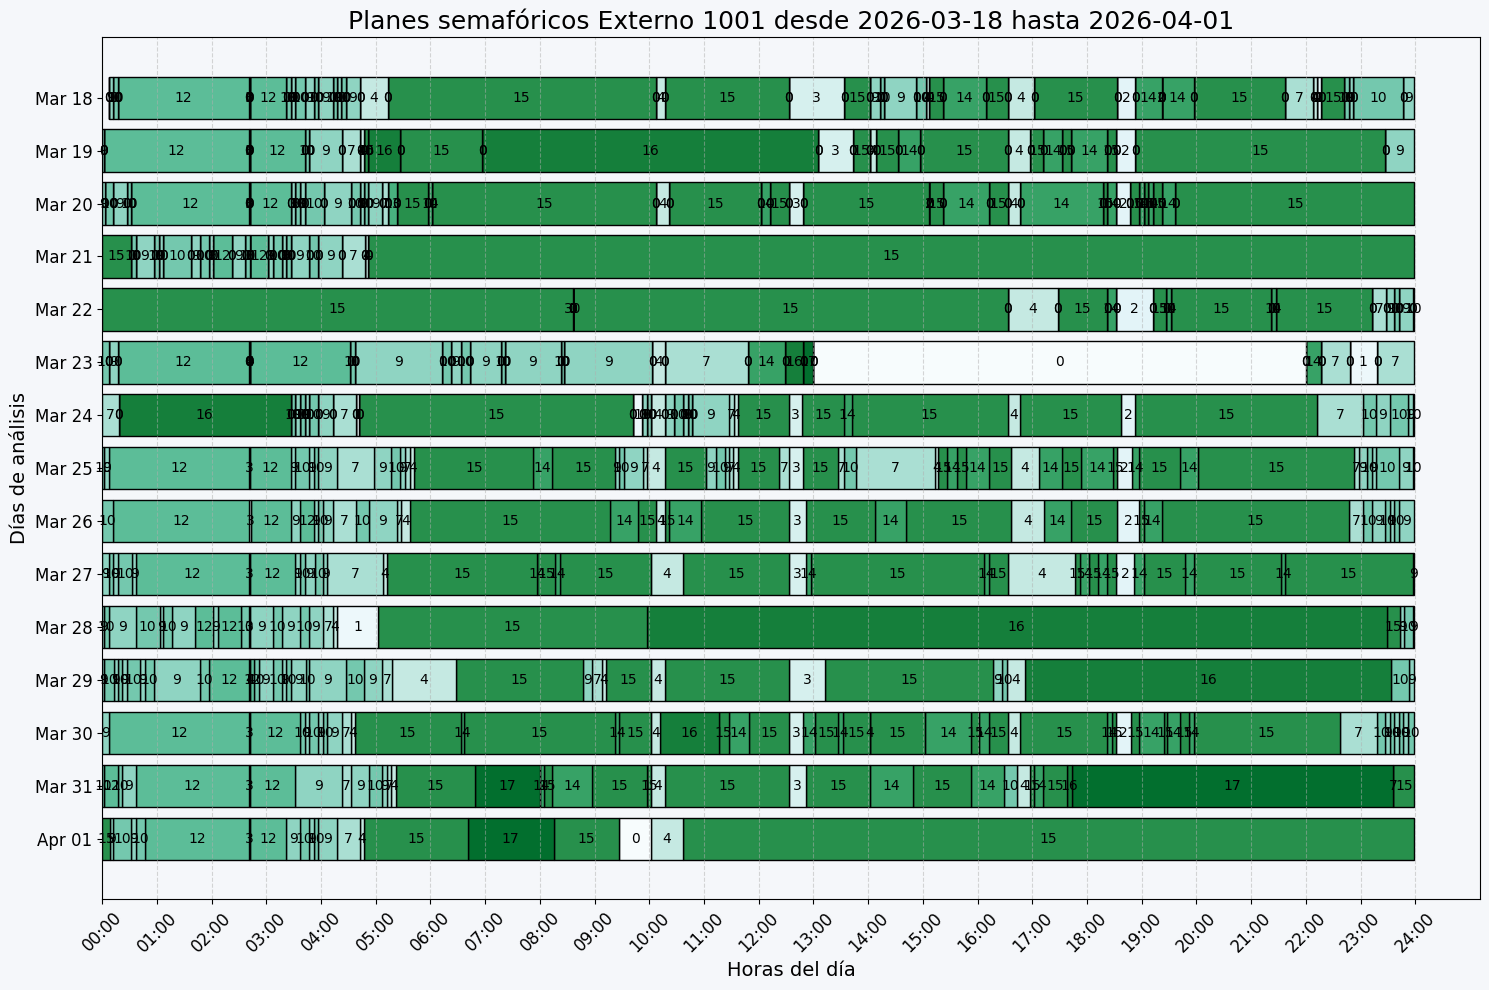

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumimos que tienes cargado planes_ord
df_filtrado = planes_ord[planes_ord['Externo'] == 3678]

# Mapear fechas a posiciones Y
fechas = sorted(df_filtrado['fecha_finaliza'].unique(), reverse=True)
mapa_fechas = {fecha: i for i, fecha in enumerate(fechas)}

fig, ax = plt.subplots(figsize=(15, 10))

# Colores únicos por plan_Final
planes_unicos = sorted(df_filtrado['plan_Final'].unique())
n_colores = len(planes_unicos)

# Obtener el colormap continuo y muestrearlo
colormap = plt.colormaps.get_cmap('BuGn')
colores = [colormap(i / n_colores) for i in range(n_colores)]  # Escalamos de 0 a 1

# Mapear los colores a los planes
mapa_colores = {plan: colores[i] for i, plan in enumerate(planes_unicos)}

for _, row in df_filtrado.iterrows():
    y_pos = mapa_fechas[row['fecha_finaliza']]
    ax.barh(
        y=y_pos,
        width=row['duration'],
        left=row['start_minutes'],
        height=0.8,
        color=mapa_colores[row['plan_Final']],
        edgecolor='black'
    )
    ax.text(
        x=row['start_minutes'] + row['duration'] / 2,
        y=y_pos,
        s=str(row['plan_Final']),
        va='center',
        ha='center',
        fontsize=10,
        color='black'
    )

# Ejes
ax.set_yticks(list(mapa_fechas.values()))
ax.set_yticklabels([fecha.strftime('%b %d') for fecha in mapa_fechas.keys()], fontsize=12)
ax.set_xticks(range(0, 1441, 60))
ax.set_xticklabels([f"{h:02}:00" for h in range(25)], rotation=45, fontsize=12)

# Títulos
EXT = 1001
begin = min(mapa_fechas.keys()).strftime('%Y-%m-%d')
fin = max(mapa_fechas.keys()).strftime('%Y-%m-%d')
ax.set_title(f"Planes semafóricos Externo {EXT} desde {begin} hasta {fin}", fontsize=18)
ax.set_xlabel("Horas del día", fontsize=14)
ax.set_ylabel("Días de análisis", fontsize=14)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_facecolor('#f5f7fa')
fig.patch.set_facecolor('#f5f7fa')

plt.savefig("C:/Users/jagarcia/Documents/SEMAFOROS/09_PLANES_SEMA/01_analisis_plangrafico_planes.png", dpi=300)
plt.tight_layout()
plt.show()